In [16]:
import numpy as np
import matplotlib.pyplot as plt
import wildfire
from wildfire.utils.functions import G
from wildfire.utils import plots, gradient
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


t:  0.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


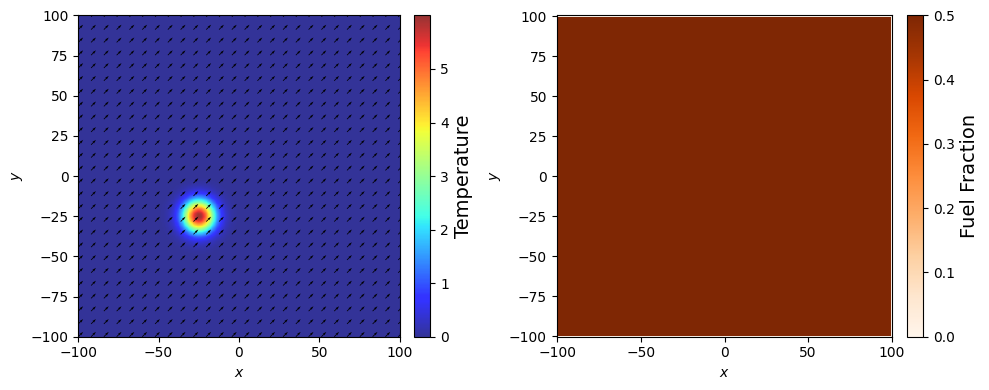

t:  1.2333333333333334
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


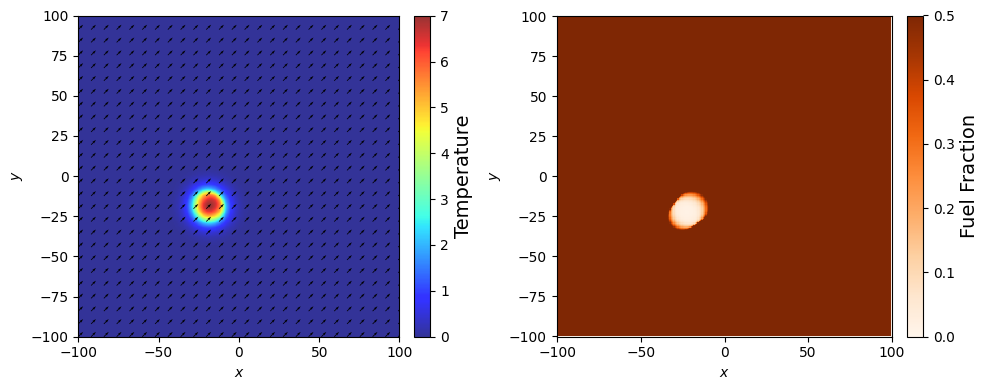

t:  2.5
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


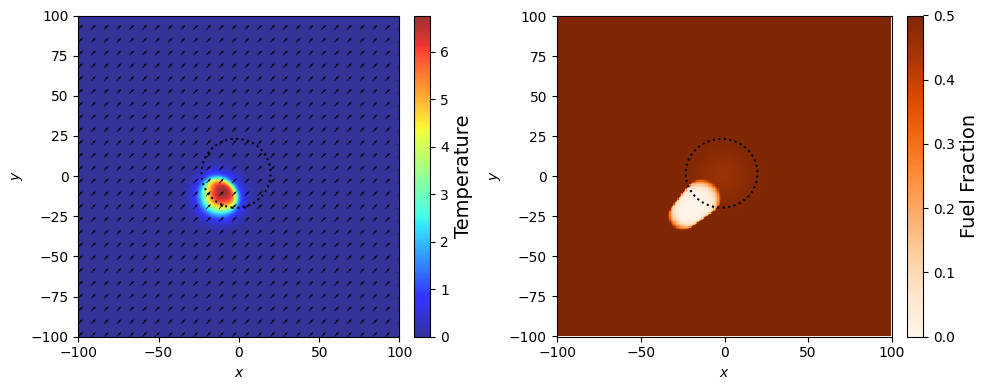

t:  3.7333333333333334
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


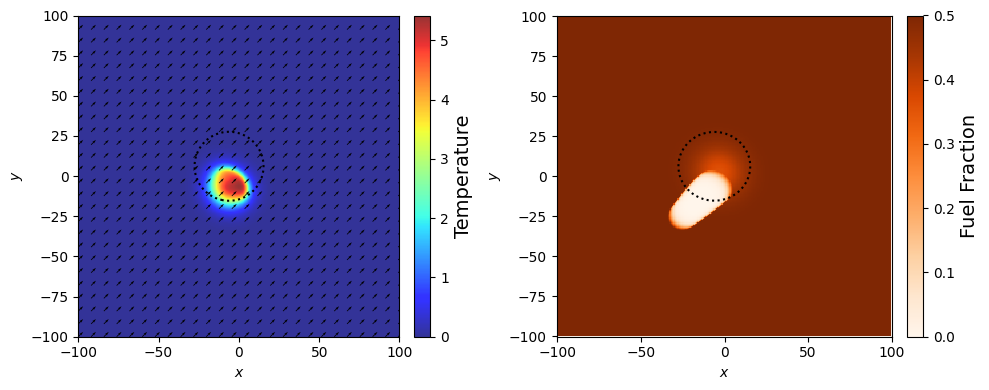

t:  5.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


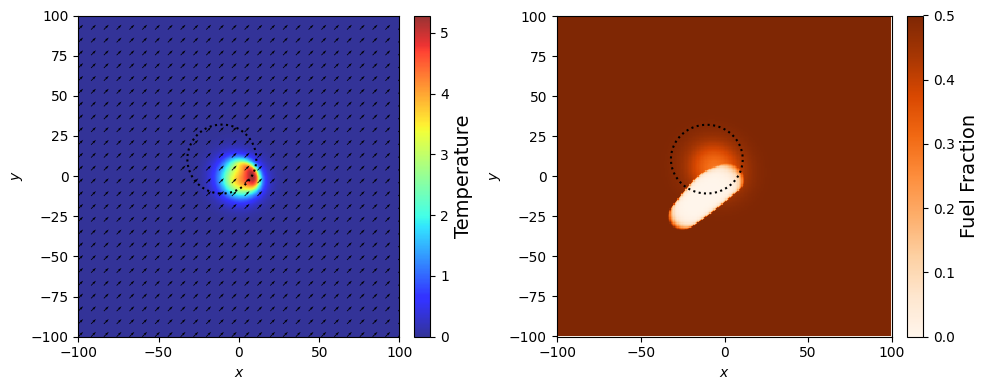

In [22]:
### Forward Solve 

# Model parameters #
kap = 1
eps = 3e-1
upc = 3.
alp = 1e-3
q = 1
x_min, x_max = -100, 100
y_min, y_max = -100, 100
t_min, t_max = 0, 5

# Numerical #
# Space
space_method = 'FD'
Nx = 252
Ny = 252
acc = 2
sparse = False

# Time
time_method = 'Euler'
Nt = 150
last = False

# Initial conditions
u0 = lambda x, y: 6 * G(x+25, y+25, 100)

# different initial fuel condition
def b1(x,y):
    B = 0.5 * np.ones_like(x)
    x_rows, x_cols = x.shape
    y_rows, y_cols = y.shape
    B[0,:] = np.zeros(x_cols)
    B[-1,:] = np.zeros(x_cols)
    B[:,0] = np.zeros(y_rows)
    B[:,-1] = np.zeros(y_rows)
    return B

# Fuel initial condition
def b0(x, y):
    np.random.seed(666)
    br = lambda x, y: np.round(np.random.uniform(size=(x.shape)), decimals=2)
    B = br(x, y) 
    x_rows, x_cols = x.shape
    y_rows, y_cols = y.shape
    B[0,:] = np.zeros(x_cols)
    B[-1,:] = np.zeros(x_cols)
    B[:,0] = np.zeros(y_rows)
    B[:,-1] = np.zeros(y_rows)
    return B

# Wind effect
gamma = 7
w1 = lambda x, y, t: gamma * np.cos(np.pi/4 + x * 0)
w2 = lambda x, y, t: gamma * np.sin(np.pi/4 + x * 0)
V = lambda x, y, t: (w1(x, y, t), w2(x, y, t))
### PARAMETERS ###

# Physical parameters for the model
physical_parameters = {    
    'kap': kap, # diffusion coefficient
    'eps': eps, # inverse of activation energy
    'upc': upc, # u phase change
    'q': q, # reaction heat
    'alp': alp, # natural convection,
    # Domain
    'x_lim': (x_min, x_max), # x-axis domain 
    'y_lim': (y_min, y_max), # y-axis domain
    't_lim': (t_min, t_max) # time domain
}

drop_1 = [0, 0, 3*np.pi/4, 2]
# drop_2 = [20, 20, (3/4)*np.pi, 6]
drop_opt = np.asarray([-2.134e+01, -2.270e+01,  9.240e-01,  0.000e+00])
control_vars = np.asarray([drop_1])   #, drop_2])

# CONTROL PARAMETERS
control_params = {
    'v':5,
    'sigma_x':10,
    'sigma_y':10,
    'T':3,
    'k': 0.5,
    'delta': 0.2,
    'control_vars':control_vars
}

wildfire_ = wildfire.Fire(**physical_parameters, control_params=control_params)
t, X, Y, U, B = wildfire_.solvePDE(Nx, Ny, Nt, u0, b1, V, space_method, time_method, last=False, acc=acc, sparse=sparse)

# calculate and print Peclet and CFL numbers, according to following formulas
# peclet = (1 * Length) / diffusion const
# # set wind=1 for now.

## Plot results
Ns = np.linspace(0, Nt, 5, dtype=int)
for n in Ns:
    plots.UBs(n, t, X, Y, U, B, V, control_params, forward=True)


In [23]:
# Prepare for Adjoint computation -> check shapes of U and B and determine terminal conditions for rho_u and rho_beta

print(U.shape[0])
print(B.shape)

# introduce mask for Beta < thereshold in terminal condition computation
threshold = 0.001
B0 = B[0,:,:]
mask = B0 > threshold
rho_u_terminal = np.zeros((U.shape[1], U.shape[2])) # terminal condition is rho_u = 0 across the grid.
rho_b_terminal = np.zeros_like(B0)
rho_b_terminal[mask] = -0.5 / B0[mask] # terminal condition here is W(X) / B_0(X), set W(X) = 0.5 uniformly for now.
# - (0.5 / (B[0,:,:] + 1e-3)) 

t1, X1, Y1, rho_u, rho_b = wildfire_.solve_adjointPDE(Nx, Ny, Nt, rho_u_terminal, rho_b_terminal, U, B, V, 
        space_method, time_method, last=False, acc=acc, sparse=sparse)


151
(151, 252, 252)


t:  5.0
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


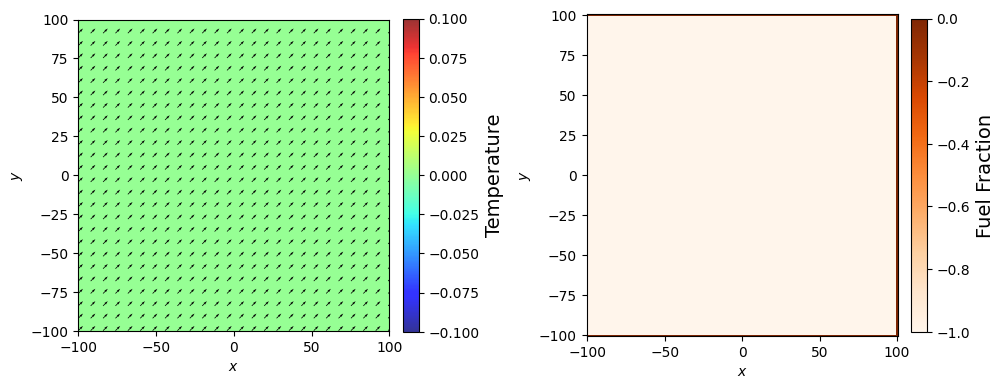

t:  3.7666666666666666
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


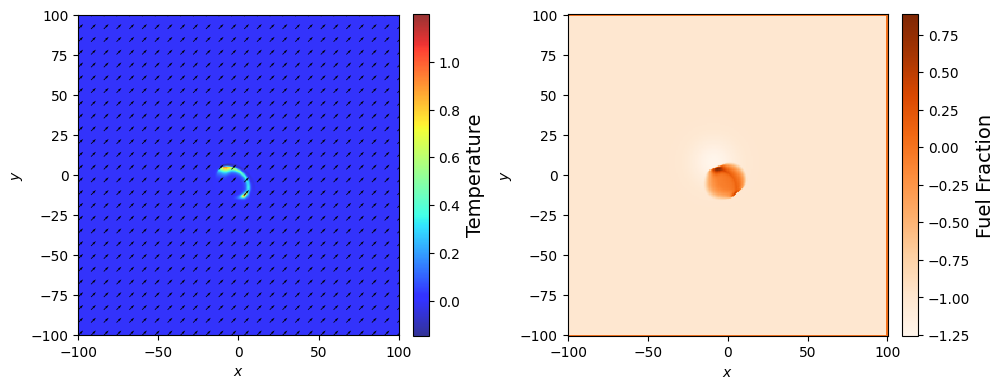

t:  2.533333333333333
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


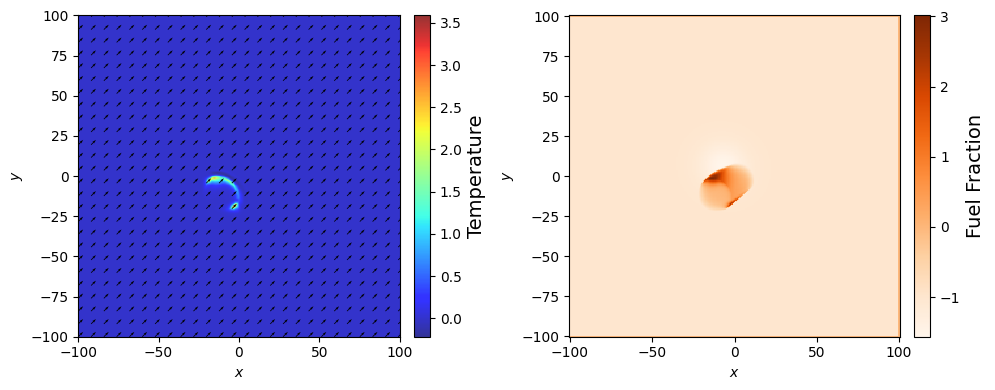

t:  1.3000000000000003
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


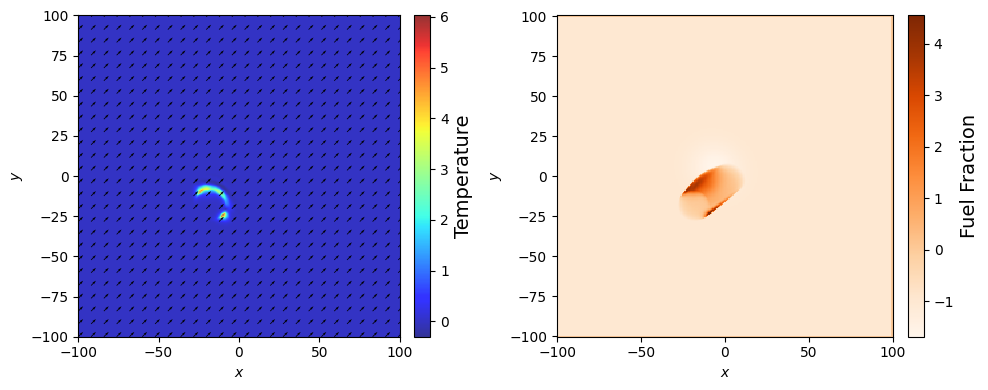

t:  0.06666666666666643
V1: [4.949747, 4.949747], V2: [4.949747, 4.949747]


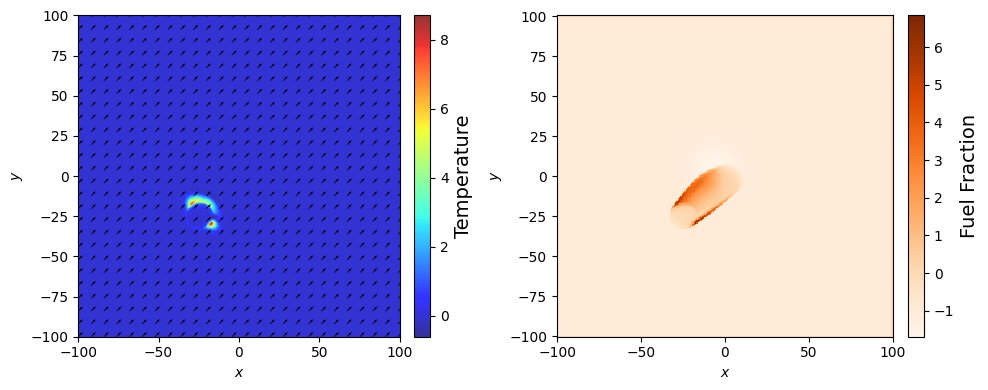

In [25]:
## Plot results
Ns = np.arange(Nt + 1)[::Nt // 4]
for n in Ns:
    plots.UBs(n, t1, X1, Y1, rho_u, rho_b, V, control_params=None, forward=False)


In [26]:
# try computing gradient
gradient_calculator = gradient.gradient(control_vars, control_params, X, Y, t)

grad = gradient_calculator.compute_gradient(U, B, rho_u, rho_b)

print(grad)

[  8.17947207  17.68153311 -67.44604379  60.06691241]
